<a href="https://colab.research.google.com/github/amir-asari/SEBB4083-Assignment2025/blob/main/G6_GRP_ASSIGNMENT2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> # **Mini Project 2025 (Pain Facial Expression Detection)**

### Total marks: 15 Marks

### Group No : 6

###Group Members:

1) RAFIZUYAIDI BIN RAMLI

2) NUR FATHIAH BINTI ROSMADI

3) MUHAMMAD HAZIQ BIN MOHAMMAD JAIS

4) YAP CHO RUI

5) OMER KHALID OMER ABDULALEEM




## **Chapter 1: Introduction**


**1.1.1 Importance of Automated Pain Detection**

Pain assessment is a critical component of clinical decision-making, as it provides essential information for diagnosis, treatment planning, and patient monitoring. However, conventional pain assessment methods largely rely on self-reporting, which is not feasible for non-verbal or cognitively impaired patients, such as infants, patients with severe dementia, unconscious individuals, or patients under sedation. In these populations, pain is often underestimated or misinterpreted, leading to inadequate treatment and reduced quality of care.

To address this limitation, researchers have explored automated pain detection systems based on physiological signals and facial expressions. Facial expression analysis is particularly promising, as facial movements are natural and involuntary indicators of pain. However, collecting real patient facial data poses significant challenges, including privacy concerns, ethical approval constraints, and demographic bias. To overcome these limitations, Taati et al. (2025) introduced SynPAIN, a validated synthetic dataset consisting of pain and no-pain facial expressions generated using artificial intelligence. This dataset enables researchers to develop and evaluate pain detection models without compromising patient privacy while improving data diversity.

**1.1.2 Related Work in Pain Detection and Medical Image Classification**

Recent studies have demonstrated the effectiveness of deep learning, particularly Convolutional Neural Networks (CNNs), in medical image classification tasks. CNN-based models have been successfully applied to brain tumour classification, gastrointestinal disease detection, and other medical imaging problems due to their ability to automatically extract hierarchical features from images.

Kumar et al. (2024) employed EfficientNetB0 for brain tumour classification using MRI images and achieved high diagnostic accuracy with reduced computational cost. Similarly, UÇan et al. (2022) demonstrated that EfficientNet-B0 is effective for multi-class gastrointestinal image classification, highlighting its strong feature extraction capability and efficiency. These findings indicate that EfficientNet architectures are well-suited for medical imaging tasks where accuracy and computational efficiency are both critical.

In the context of pain detection, deep learning approaches have increasingly been adopted to classify facial expressions into pain and no-pain categories. The SynPAIN study by Taati et al. (2025) demonstrated that transfer learning-based CNN models trained on synthetic facial data can achieve competitive performance while addressing ethical and data scarcity issues. Inspired by this work, the present project adopts a similar methodology using transfer learning to classify synthetic facial expressions.

**1.1.3 EfficientNetB0 Architecture**

EfficientNetB0 is a modern convolutional neural network architecture that introduces a compound scaling method, which uniformly scales the network’s depth, width, and input resolution using a fixed set of scaling coefficients. Unlike traditional CNN architectures that scale these dimensions independently, EfficientNet ensures an optimal balance between model size and performance.

EfficientNetB0 is the baseline model of the EfficientNet family and is designed to achieve high accuracy with a relatively small number of parameters. This makes it particularly suitable for applications with limited computational resources, such as Google Colab’s free environment. The architecture consists of Mobile Inverted Bottleneck Convolution (MBConv) blocks, squeeze-and-excitation layers, and depthwise separable convolutions, which significantly reduce computational cost while maintaining strong feature representation.

Due to its efficiency and proven performance in medical image classification tasks, EfficientNetB0 was selected in this project to classify facial expressions into pain and no-pain categories using synthetic data.

**1.1.4 Motivation for Using Transfer Learning**

Transfer learning is a widely adopted technique in deep learning, especially in medical imaging applications where labeled data is often limited. Instead of training a model from scratch, transfer learning leverages pre-trained models that have already learned rich feature representations from large-scale datasets such as ImageNet.

Alzubaidi et al. (2021) demonstrated that transfer learning significantly improves performance in medical imaging tasks with limited labeled data by reducing overfitting and accelerating convergence. Similarly, Iman et al. (2023) highlighted that deep transfer learning enables models to generalize better by reusing low-level and mid-level features learned from large datasets.

In this project, EfficientNetB0 pre-trained on ImageNet is used as the feature extractor, while the final classification layers are fine-tuned for the pain detection task. This approach reduces training time, improves stability, and enhances classification accuracy, making it suitable for analyzing synthetic facial expression data.

**1.2 Objectives**

The primary objective of this mini-project is to develop an automated pain detection system using transfer learning with the EfficientNetB0 architecture to classify synthetic facial expression images into Pain and No Pain categories. Using the SynPAIN synthetic dataset, this study aims to systematically analyze how different training strategies influence model performance.

Specifically, the objectives of this study are:

1. To evaluate the effect of data augmentation techniques (rotation, zoom, and horizontal flipping) on the classification performance of EfficientNetB0 when trained on synthetic facial expression data.

2. To investigate the impact of key hyperparameters, particularly the learning rate, on model convergence, training stability, and final classification accuracy.

3. To analyze the influence of different training–testing data split ratios on the generalization ability of the model in the context of synthetic data.

4. To assess the suitability and reliability of synthetic facial expression data for automated pain detection tasks using deep learning approaches.

## **Chapter 2: Methodology & Result**








###**Methodology: Data Preparation and Experimental Setup**

**2.1 Data Partitioning**

To evaluate the model's robustness we conducted three different experiments. First experiment is where we analyze data split based on accuracy or loss for train, and other 2 experiment perform on chosen data split ratio. The raw dataset was programmatically split into Training and Testing sets using the following ratios:

    Experiment A: 70% Training / 30% Testing

    Experiment B: 80% Training / 20% Testing

    Experiment C: 90% Training / 10% Testing

For each split, the train_test_split function was executed with a fixed random seed (random_state=42). This ensured that the class distribution (Pain vs. NoPain) remained balanced and reproducible across all experiments. The resulting images were physically sorted into separate directory trees, allowing the memory-efficient ImageDataGenerator to stream data directly from these specific folders during training.


**2.2 Data Loading and Augmentation**

We used a tool from Keras called ImageDataGenerator to handle the images. Instead of loading thousands of images into the computer's memory (RAM) all at once, which could cause the system to crash, this tool loads the images in small groups (batches) only when they are needed for training. This makes the process much smoother and saves memory.


**Image Preparation (Preprocessing)**

Before the images are fed into the model, they go through two important steps:

1. *Normalization:* We use a function called preprocess_input to adjust the color values of the images so they are in the exact format the EfficientNetB0 model expects.

2. *Resizing:* Since the EfficientNetB0 model requires inputs of a specific size, we automatically resize all images to 224 × 224 pixels.

**Data Augmentation**

To prevent the model from just "memorizing" the training images (a problem called overfitting), we used a technique called Data Augmentation. This technique creates new versions of our training images by applying random changes. Every time an image is loaded, it is slightly altered using the settings below:

1. *Rotation* : The image is randomly rotated by up to 20 degrees.

2. *Shifting* : The image is moved slightly left/right or up/down (by 20%).

3. *Zooming* : The camera appears to zoom in or out by 20%.

4. *Flipping* : The image is mirrored horizontally (like looking in a mirror).

This forces the model to learn what "Pain" looks like from different angles and positions, making it smarter and more accurate on new data.

**2.3 Software Environment and Library Setup**

To begin the project, we set up the coding environment by importing the necessary Python libraries. These libraries provide the specific tools needed for building the AI model and handling data:

1. Deep Learning Framework: We imported *TensorFlow* and *Keras* (tensorflow, keras, layers, models). These are the core engines used to build, train, and evaluate the EfficientNetB0 model.

2. Data Handling: Libraries like *numpy* were used for numerical calculations, while os and shutil were imported to help the system navigate folders and move files around the computer.

3. Visualization: We imported *matplotlib.pyplot* and *matplotlib*.image to create graphs and display the actual images to check if they look correct.

4. Splitting Data: The *train_test_split* function from sklearn was imported to help us mathematically divide our data into training and testing sets later on.

**2.4 Data Acquisition and Extraction**

The dataset used for this experiment (stored as *SynPain_Resized.zip*) was hosted remotely. We used the following steps to load it into the environment:

1. Downloading: The command *!gdown* was used to download the zip file directly from Google Drive using its unique file ID.

2. Extraction: We used the *zipfile36* library to unzip the file. The code *zipObj.extractall()* automatically unpacked all the images into the local directory so they could be accessed by the code.

3. Configuration: We also defined global settings here, setting the image height and width to 224x224 pixels (to match the model's requirements) and the batch size to 32.

###**Methodology: Coding and Result**

Importing libary that needed for our project and also install zip file that required for unzip the zip file

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import random

import tensorflow as tf
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.image as mpimg
from tensorflow.keras.applications import EfficientNetB0
from tensorflow import keras

from sklearn.model_selection import train_test_split

!pip install zipfile36
from zipfile36 import ZipFile

#####**Task 1 – Data Acquisition & Preparation**

insert our link to google drive downloader to achieve correct directory path to our target folder or file

In [ ]:
! gdown 1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW

Downloading...
From (original): https://drive.google.com/uc?id=1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW
From (redirected): https://drive.google.com/uc?id=1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW&confirm=t&uuid=3f819609-f80b-4f5d-80af-fed3ba54cdfc
To: /content/SynPain_Resized.zip
100% 73.0M/73.0M [00:01<00:00, 42.3MB/s]


Extract our ZIP file to gain all the information inside the folder

In [ ]:
with ZipFile('/content/SynPain_Resized.zip','r') as zipObj:
  zipObj.extractall()

due to EfficientNetB0 required input 224x224, we resized or reshape our image to that specific requirement, also adding batch size

In [ ]:
img_height  = 224
img_width   = 224
batch_size  = 32

now the visualization part where, we display 3x3 random image of every category in our data. the categories are no pain and pain image.

Displaying 'Pain' samples:


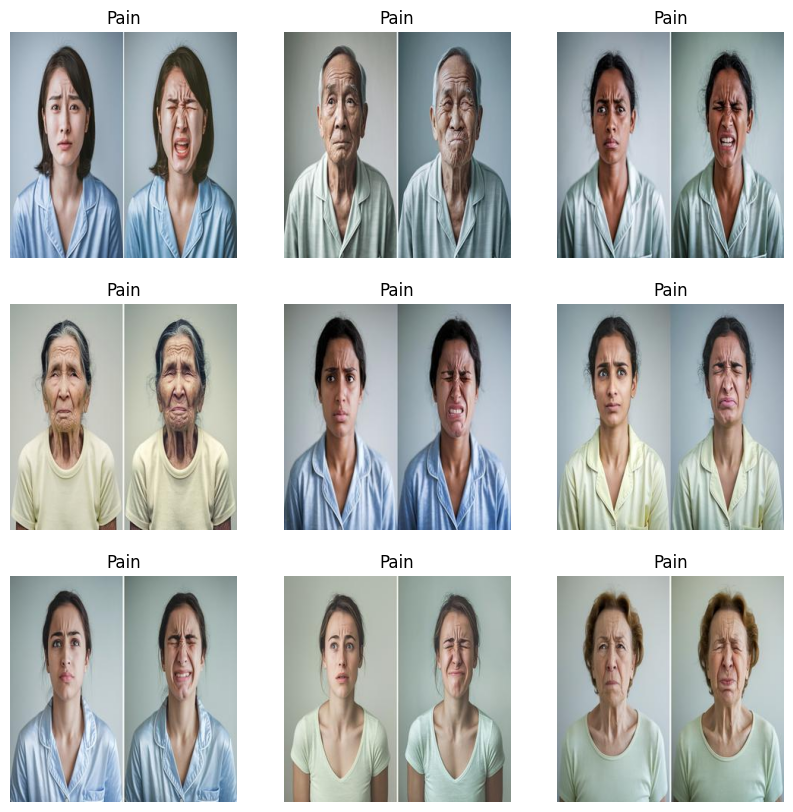

Displaying 'NoPain' samples:


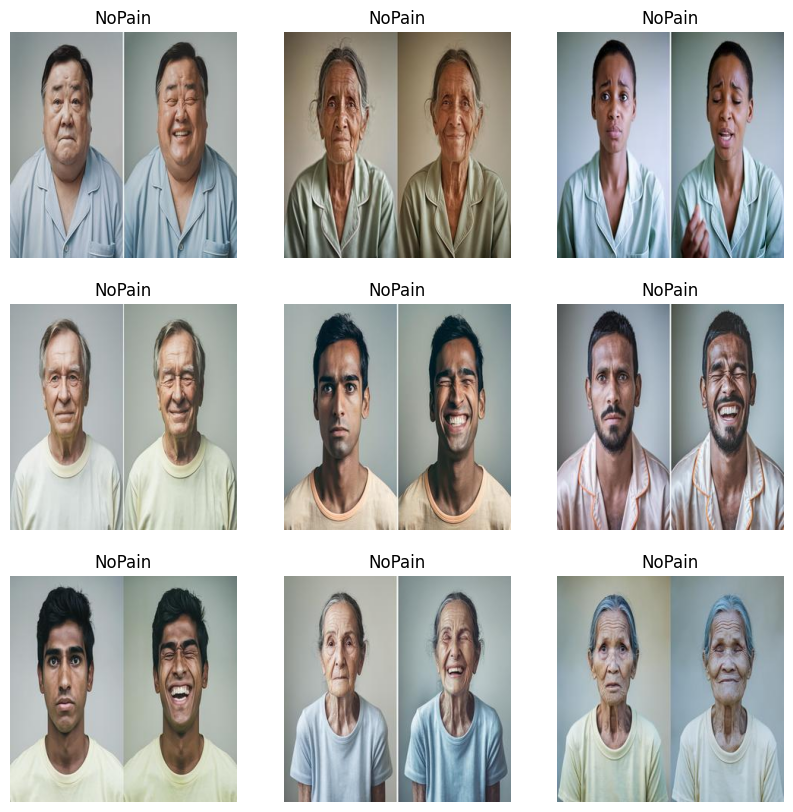

In [ ]:
dataset_dir = '/content/SynPain_Resized'

def show_sample_images(class_name):
    # Construct the full path to the class folder (e.g., .../Pain)
    target_folder = next((d for d in os.listdir(dataset_dir) if class_name.lower() in d.lower()), None)

    if not target_folder:
        print(f"Error: Could not find folder for {class_name}")
        return

    full_path = os.path.join(dataset_dir, target_folder)
    all_images = os.listdir(full_path)

    # Select 3 random images to display
    selected_images = random.sample(all_images, 9)

    plt.figure(figsize=(10, 10)) # Set figure size
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(full_path, img_name)
        img = mpimg.imread(img_path) # Read image

        plt.subplot(3, 3, i + 1) # Create subplot
        plt.imshow(img)
        plt.axis('off') # Hide axes
        plt.title(f"{class_name}")
    plt.show()

# 3. Run the visualization
print("Displaying 'Pain' samples:")
show_sample_images("Pain")

print("Displaying 'NoPain' samples:")
show_sample_images("NoPain")

#####**Task 2 – Model Development & Experimental Analysis**

In [ ]:
# Define the path to the directory where you want to create the train and test folders
output_dir = '/content/output80'

# Define the percentage of data to be used for testing
test_split = 0.2

# Get the list of subfolders in the dataset directory
subfolders = [subfolder for subfolder in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, subfolder))]

print(subfolders)

# Define the train and test folder paths
train_dir = os.path.join(output_dir, 'train')
test_dir = os.path.join(output_dir, 'test')

# Delete train and test folders if they already exist
if os.path.exists(train_dir):
    shutil.rmtree(train_dir)
if os.path.exists(test_dir):
    shutil.rmtree(test_dir)

# Create the train and test folders in the output directory
os.makedirs(train_dir)
os.makedirs(test_dir)

# Iterate over each subfolder and split the images into train and test sets
for subfolder in subfolders:
    subfolder_path = os.path.join(dataset_dir, subfolder)
    images = os.listdir(subfolder_path)
    train_images, test_images = train_test_split(images, test_size=test_split, random_state=42)

    # Create the subfolders inside train and test directories
    train_subfolder_dir = os.path.join(train_dir, subfolder)
    test_subfolder_dir = os.path.join(test_dir, subfolder)
    os.makedirs(train_subfolder_dir)
    os.makedirs(test_subfolder_dir)

    # Move the train images to the train folder
    for image in train_images:
        src = os.path.join(subfolder_path, image)
        dst = os.path.join(train_dir, subfolder, image)
        print(src)
        print(dst)
        shutil.copyfile(src, dst)

    # Move the test images to the test folder
    for image in test_images:
        src = os.path.join(subfolder_path, image)
        dst = os.path.join(test_dir, subfolder, image)
        shutil.copyfile(src, dst)

Streaming output truncated to the last 5000 lines.
/content/SynPain_Resized/Pain/1101015350_Pain_man_Old.jpg
/content/output80/train/Pain/1101015350_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1101231090_Pain_man_Old.jpg
/content/output80/train/Pain/1101231090_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1100158320_Pain_man_Young.jpg
/content/output80/train/Pain/1100158320_Pain_man_Young.jpg
/content/SynPain_Resized/Pain/1100048400_Pain_man_Young.jpg
/content/output80/train/Pain/1100048400_Pain_man_Young.jpg
/content/SynPain_Resized/Pain/1111223450_Pain_woman_Old.jpg
/content/output80/train/Pain/1111223450_Pain_woman_Old.jpg
/content/SynPain_Resized/Pain/1101050900_Pain_man_Old.jpg
/content/output80/train/Pain/1101050900_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1110414140_Pain_woman_Young.jpg
/content/output80/train/Pain/1110414140_Pain_woman_Young.jpg
/content/SynPain_Resized/Pain/1101422890_Pain_man_Old.jpg
/content/output80/train/Pain/1101422890_Pain_man_Old.jpg
/content/

now here we splitting our data to training set and test set, the ratio that we choose is 70% for training data adn 30% for test data. these data will be saved or store in output folder inside content. at the test_split part will be changed according to Experiment 1 that required us to conduct analysis about the effect of splitting data. we used three cases which are 70/30, 80/20 and 90/10.

In [ ]:
# Define the path to the directory where you want to create the train and test folders
output_dir = '/content/output70'

# Define the percentage of data to be used for testing
test_split = 0.3

# Get the list of subfolders in the dataset directory
subfolders = [subfolder for subfolder in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, subfolder))]

print(subfolders)

# Define the train and test folder paths
train_dir = os.path.join(output_dir, 'train')
test_dir = os.path.join(output_dir, 'test')

# Delete train and test folders if they already exist
if os.path.exists(train_dir):
    shutil.rmtree(train_dir)
if os.path.exists(test_dir):
    shutil.rmtree(test_dir)

# Create the train and test folders in the output directory
os.makedirs(train_dir)
os.makedirs(test_dir)

# Iterate over each subfolder and split the images into train and test sets
for subfolder in subfolders:
    subfolder_path = os.path.join(dataset_dir, subfolder)
    images = os.listdir(subfolder_path)
    train_images, test_images = train_test_split(images, test_size=test_split, random_state=42)

    # Create the subfolders inside train and test directories
    train_subfolder_dir = os.path.join(train_dir, subfolder)
    test_subfolder_dir = os.path.join(test_dir, subfolder)
    os.makedirs(train_subfolder_dir)
    os.makedirs(test_subfolder_dir)

    # Move the train images to the train folder
    for image in train_images:
        src = os.path.join(subfolder_path, image)
        dst = os.path.join(train_dir, subfolder, image)
        print(src)
        print(dst)
        shutil.copyfile(src, dst)

    # Move the test images to the test folder
    for image in test_images:
        src = os.path.join(subfolder_path, image)
        dst = os.path.join(test_dir, subfolder, image)
        shutil.copyfile(src, dst)

Streaming output truncated to the last 5000 lines.
/content/SynPain_Resized/Pain/1101254180_Pain_man_Old.jpg
/content/output70/train/Pain/1101254180_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1110128030_Pain_woman_Young.jpg
/content/output70/train/Pain/1110128030_Pain_woman_Young.jpg
/content/SynPain_Resized/Pain/1110259060_Pain_woman_Young.jpg
/content/output70/train/Pain/1110259060_Pain_woman_Young.jpg
/content/SynPain_Resized/Pain/1101456180_Pain_man_Old.jpg
/content/output70/train/Pain/1101456180_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1101025370_Pain_man_Old.jpg
/content/output70/train/Pain/1101025370_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1101422540_Pain_man_Old.jpg
/content/output70/train/Pain/1101422540_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1101257070_Pain_man_Old.jpg
/content/output70/train/Pain/1101257070_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1110228010_Pain_woman_Young.jpg
/content/output70/train/Pain/1110228010_Pain_woman_Young.jpg
/cont

In [ ]:
# Define the path to the directory where you want to create the train and test folders
output_dir = '/content/output90'

# Define the percentage of data to be used for testing
test_split = 0.1

# Get the list of subfolders in the dataset directory
subfolders = [subfolder for subfolder in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, subfolder))]

print(subfolders)

# Define the train and test folder paths
train_dir = os.path.join(output_dir, 'train')
test_dir = os.path.join(output_dir, 'test')

# Delete train and test folders if they already exist
if os.path.exists(train_dir):
    shutil.rmtree(train_dir)
if os.path.exists(test_dir):
    shutil.rmtree(test_dir)

# Create the train and test folders in the output directory
os.makedirs(train_dir)
os.makedirs(test_dir)

# Iterate over each subfolder and split the images into train and test sets
for subfolder in subfolders:
    subfolder_path = os.path.join(dataset_dir, subfolder)
    images = os.listdir(subfolder_path)
    train_images, test_images = train_test_split(images, test_size=test_split, random_state=42)

    # Create the subfolders inside train and test directories
    train_subfolder_dir = os.path.join(train_dir, subfolder)
    test_subfolder_dir = os.path.join(test_dir, subfolder)
    os.makedirs(train_subfolder_dir)
    os.makedirs(test_subfolder_dir)

    # Move the train images to the train folder
    for image in train_images:
        src = os.path.join(subfolder_path, image)
        dst = os.path.join(train_dir, subfolder, image)
        print(src)
        print(dst)
        shutil.copyfile(src, dst)

    # Move the test images to the test folder
    for image in test_images:
        src = os.path.join(subfolder_path, image)
        dst = os.path.join(test_dir, subfolder, image)
        shutil.copyfile(src, dst)

Streaming output truncated to the last 5000 lines.
/content/SynPain_Resized/Pain/1111127500_Pain_woman_Old.jpg
/content/output90/train/Pain/1111127500_Pain_woman_Old.jpg
/content/SynPain_Resized/Pain/1110425500_Pain_woman_Young.jpg
/content/output90/train/Pain/1110425500_Pain_woman_Young.jpg
/content/SynPain_Resized/Pain/1101018350_Pain_man_Old.jpg
/content/output90/train/Pain/1101018350_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1110147750_Pain_woman_Young.jpg
/content/output90/train/Pain/1110147750_Pain_woman_Young.jpg
/content/SynPain_Resized/Pain/1101137770_Pain_man_Old.jpg
/content/output90/train/Pain/1101137770_Pain_man_Old.jpg
/content/SynPain_Resized/Pain/1110441910_Pain_woman_Young.jpg
/content/output90/train/Pain/1110441910_Pain_woman_Young.jpg
/content/SynPain_Resized/Pain/1101412031_Pain_Man_Old.jpg
/content/output90/train/Pain/1101412031_Pain_Man_Old.jpg
/content/SynPain_Resized/Pain/1110241830_Pain_woman_Young.jpg
/content/output90/train/Pain/1110241830_Pain_woman_You

In [ ]:
# Define the path to the subfolder containing the images
test7_pain_path = '/content/output70/test/Pain'
test7_nopain_path = '/content/output70/test/NoPain'
train7_pain_path = '/content/output70/train/Pain'
train7_nopain_path = '/content/output70/train/NoPain'

test8_pain_path = '/content/output80/test/Pain'
test8_nopain_path = '/content/output80/test/NoPain'
train8_pain_path = '/content/output80/train/Pain'
train8_nopain_path = '/content/output80/train/NoPain'

test9_pain_path = '/content/output90/test/Pain'
test9_nopain_path = '/content/output90/test/NoPain'
train9_pain_path = '/content/output90/train/Pain'
train9_nopain_path = '/content/output90/train/NoPain'

# Count the number of images in the subfolder
num_images17 = len([name for name in os.listdir(test7_pain_path) if os.path.isfile(os.path.join(test7_pain_path, name))])
num_images27 = len([name for name in os.listdir(test7_nopain_path) if os.path.isfile(os.path.join(test7_nopain_path, name))])
num_images37 = len([name for name in os.listdir(train7_pain_path) if os.path.isfile(os.path.join(train7_pain_path, name))])
num_images47 = len([name for name in os.listdir(train7_nopain_path) if os.path.isfile(os.path.join(train7_nopain_path, name))])

num_images18 = len([name for name in os.listdir(test8_pain_path) if os.path.isfile(os.path.join(test8_pain_path, name))])
num_images28 = len([name for name in os.listdir(test8_nopain_path) if os.path.isfile(os.path.join(test8_nopain_path, name))])
num_images38 = len([name for name in os.listdir(train8_pain_path) if os.path.isfile(os.path.join(train8_pain_path, name))])
num_images48 = len([name for name in os.listdir(train8_nopain_path) if os.path.isfile(os.path.join(train8_nopain_path, name))])

num_images19 = len([name for name in os.listdir(test9_pain_path) if os.path.isfile(os.path.join(test9_pain_path, name))])
num_images29 = len([name for name in os.listdir(test9_nopain_path) if os.path.isfile(os.path.join(test9_nopain_path, name))])
num_images39 = len([name for name in os.listdir(train9_pain_path) if os.path.isfile(os.path.join(train9_pain_path, name))])
num_images49 = len([name for name in os.listdir(train9_nopain_path) if os.path.isfile(os.path.join(train9_nopain_path, name))])

# Print the number of images in the subfolder
print(f"Number of images in the test/pain 70: {num_images17}")
print(f"Number of images in the test/nopain 70: {num_images27}")
print(f"Number of images in the train/pain 70: {num_images37}")
print(f"Number of images in the train/nopain 70: {num_images47}")

print(f"Number of images in the test/pain 80: {num_images18}")
print(f"Number of images in the test/nopain 80: {num_images28}")
print(f"Number of images in the train/pain 80: {num_images38}")
print(f"Number of images in the train/nopain 80: {num_images48}")

print(f"Number of images in the test/pain 90: {num_images19}")
print(f"Number of images in the test/nopain 90: {num_images29}")
print(f"Number of images in the train/pain 90: {num_images39}")
print(f"Number of images in the train/nopain 90: {num_images49}")

Number of images in the test/pain 70: 822
Number of images in the test/nopain 70: 786
Number of images in the train/pain 70: 1915
Number of images in the train/nopain 70: 1834
Number of images in the test/pain 80: 548
Number of images in the test/nopain 80: 524
Number of images in the train/pain 80: 2189
Number of images in the train/nopain 80: 2096
Number of images in the test/pain 90: 274
Number of images in the test/nopain 90: 262
Number of images in the train/pain 90: 2463
Number of images in the train/nopain 90: 2358


pre-processing step is very crucial. we applied data augementation only for train generator because if we applied to validation and test set as well, If we apply random flips,rotations and more to validation, our validation accuracy becomes noisy and can be misleading. not to forget, we also split 20% from training data for validation set

In [ ]:
train_data_generator = ImageDataGenerator(validation_split=0.2, preprocessing_function=preprocess_input,
rotation_range=20,
width_shift_range=0.2,
height_shift_range=0.2,
zoom_range=0.2,
horizontal_flip=True)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_data_generator = ImageDataGenerator(preprocessing_function=preprocess_input)

This is the most common meaning in transfer learning. Function ia to feeds images to the model in batches usually Loading from disk so you don’t keep everything in RAM, Resizing to the model input size (e.g., 224×224), Labeling (reads folder labels or a dataframe), Shuffling (improves training), Data augmentation (random flips/rotations/zoom) to reduce overfitting, So it’s basically a data pipeline that produces (batch_images, batch_labels) repeatedly during training.

In [ ]:
names = ["Pain" , "NoPain"] #make sure the spelling is similar to the folder name

# Create the train batch generator
train_batches7 = train_data_generator.flow_from_directory(
    '/content/output70/train',
    target_size = (img_width,img_height),
    class_mode = 'sparse', #make label as integer value
    subset='training',
    batch_size = batch_size,
    shuffle = True,
    color_mode = "rgb",
    classes = names
)

# Create the validation batch generator
validation_batches7 = train_data_generator.flow_from_directory(
    '/content/output70/train',
    target_size = (img_width,img_height),
    class_mode = 'sparse', #make label as integer value
    subset='validation',
    batch_size = batch_size,
    shuffle = True,
    color_mode = "rgb",
    classes = names
)


# Create the test generator
test_batches7 = test_data_generator.flow_from_directory(
    '/content/output70/test',
    target_size = (224,224),
    class_mode = 'sparse', #make label as integer value
    batch_size = batch_size,
    shuffle = True,
    color_mode = "rgb",
    classes = names
)

Found 3000 images belonging to 2 classes.
Found 748 images belonging to 2 classes.
Found 1607 images belonging to 2 classes.


In [ ]:
# Create the train batch generator
train_batches8 = train_data_generator.flow_from_directory(
    '/content/output80/train',
    target_size = (img_width,img_height),
    class_mode = 'sparse', #make label as integer value
    subset='training',
    batch_size = batch_size,
    shuffle = True,
    color_mode = "rgb",
    classes = names
)

# Create the validation batch generator
validation_batches8 = train_data_generator.flow_from_directory(
    '/content/output80/train',
    target_size = (img_width,img_height),
    class_mode = 'sparse', #make label as integer value
    subset='validation',
    batch_size = batch_size,
    shuffle = True,
    color_mode = "rgb",
    classes = names
)


# Create the test generator
test_batches8 = test_data_generator.flow_from_directory(
    '/content/output80/test',
    target_size = (224,224),
    class_mode = 'sparse', #make label as integer value
    batch_size = batch_size,
    shuffle = True,
    color_mode = "rgb",
    classes = names
)

Found 3427 images belonging to 2 classes.
Found 856 images belonging to 2 classes.
Found 1072 images belonging to 2 classes.


In [ ]:
names = ["Pain" , "NoPain"] #make sure the spelling is similar to the folder name

# Create the train batch generator
train_batches9 = train_data_generator.flow_from_directory(
    '/content/output90/train',
    target_size = (img_width,img_height),
    class_mode = 'sparse', #make label as integer value
    subset='training',
    batch_size = batch_size,
    shuffle = True,
    color_mode = "rgb",
    classes = names
)

# Create the validation batch generator
validation_batches9 = train_data_generator.flow_from_directory(
    '/content/output90/train',
    target_size = (img_width,img_height),
    class_mode = 'sparse', #make label as integer value
    subset='validation',
    batch_size = batch_size,
    shuffle = True,
    color_mode = "rgb",
    classes = names
)


# Create the test generator
test_batches9 = test_data_generator.flow_from_directory(
    '/content/output90/test',
    target_size = (224,224),
    class_mode = 'sparse', #make label as integer value
    batch_size = batch_size,
    shuffle = True,
    color_mode = "rgb",
    classes = names
)

Found 3856 images belonging to 2 classes.
Found 963 images belonging to 2 classes.
Found 536 images belonging to 2 classes.


uploading EfficientNetB0 to our base model and displaying the EfficientNetB0 architecture

In [ ]:
base_model = tf.keras.applications.EfficientNetB0()
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,330,571 (20.33 MB)

 Trainable params: 5,288,548 (20.17 MB)

 Non-trainable params: 42,023 (164.16 KB)

In this approach, the pre-trained model (the Base Model or Backbone) is treated as a powerful, static feature processor.the Mechanism is The weights of the entire pre-trained model are frozen (made non-trainable). The model is used solely to generate high-quality feature embeddings (numerical representations) from the new, raw input data. for training, Only a simple, small new classification layer (or output head) is added on top of the frozen base. This new head is then trained from scratch using the new dataset. Advantage of this approach is This method is fast and computationally cheap because only the small top layer is being trained. It is ideal when the new dataset is very small or when the new task is very similar to the original pre-training task.

In [ ]:
efficient_net = EfficientNetB0(weights = 'imagenet',
                               include_top = False,
                               input_shape = (img_height, img_width, 3))
# freezing the bottom layers
for layer in efficient_net.layers:
  layer.trainable = False

create our model layer that name as sequential. the first layer will be filled with effecient_net that we already declare in above code. next is our Global Average Pooling 2D that is a neural network technique that drastically reduces spatial dimensions (height and width) of 2D feature maps by averaging all values within each channel, collapsing each map to a single value, creating a concise feature vector that's less prone to overfitting than traditional pooling or flattening then we passed to our next connected layer with number of neuron is set to 1024 and activation function set to relu. ReLU (Rectified Linear Unit) in a Convolutional Neural Network (CNN) is an activation function that introduces non-linearity, allowing the network to learn complex patterns by outputting the input directly if positive, and zero if negative. next layer is set with number of neuron is 512 and also activation is set to relu. lastly is our output layer that contain number of neuron is 2 with activation is sigmoid. sigmoid is used because our output is binary or in our case is pain and no pain.

EXPERIMENT A:

In [ ]:
def build_model(learning_rate=0.001):
    efficient_net.trainable = False  # freeze backbone (if you want)

    model = keras.Sequential([
        efficient_net,
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(2, activation='softmax'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',  # softmax output
        metrics=['accuracy']
    )
    return model

In [ ]:
# 70:30 (for example: train_batches7, validation_batches7)
model_70 = build_model()
history1 = model_70.fit(
    train_batches7,
    validation_data=validation_batches7,
    epochs=6,
    verbose=1
)

# 80:20 (train_batches8, validation_batches8)
model_80 = build_model()
history2 = model_80.fit(
    train_batches8,
    validation_data=validation_batches8,
    epochs=6,
    verbose=1
)

# 90:10 (train_batches9, validation_batches9)
model_90 = build_model()
history3 = model_90.fit(
    train_batches9,
    validation_data=validation_batches9,
    epochs=6,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 109s 843ms/step - accuracy: 0.6530 - loss: 0.6613 - val_accuracy: 0.5682 - val_loss: 0.7609
Epoch 2/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 473ms/step - accuracy: 0.7081 - loss: 0.5645 - val_accuracy: 0.5642 - val_loss: 0.8718
Epoch 3/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 495ms/step - accuracy: 0.7380 - loss: 0.5131 - val_accuracy: 0.7273 - val_loss: 0.5286
Epoch 4/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 473ms/step - accuracy: 0.7766 - loss: 0.4647 - val_accuracy: 0.7099 - val_loss: 0.5487
Epoch 5/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 477ms/step - accuracy: 0.7791 - loss: 0.4622 - val_accuracy: 0.7567 - val_loss: 0.4946
Epoch 6/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 475ms/step - accuracy: 0.7814 - loss: 0.4590 - val_accuracy: 0.6217 - val_loss: 0.6623
Epoch 1/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 102s 731ms/step - accuracy: 0.6044 - loss: 0.7756 - val_accuracy: 0.7033 - val_loss: 0.5729
Epoch 2/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 51s 470ms/step - accuracy: 0.7181 - loss: 0.5412 - val_accura

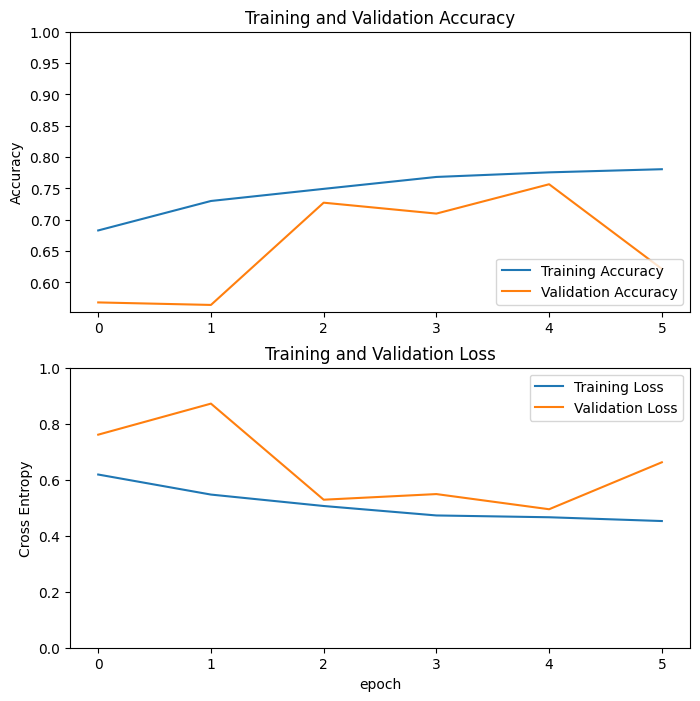

In [ ]:
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

loss = history1.history['loss']
val_loss = history1.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

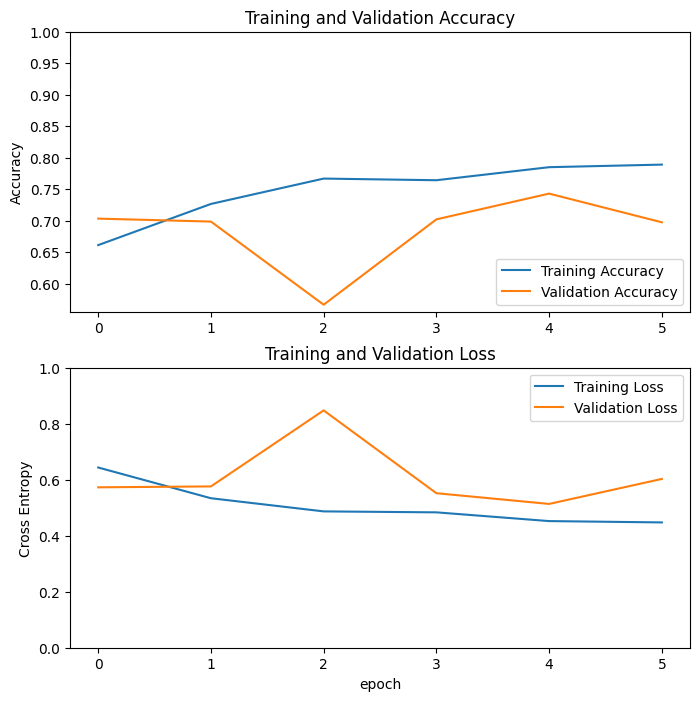

In [ ]:
acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

loss = history2.history['loss']
val_loss = history2.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

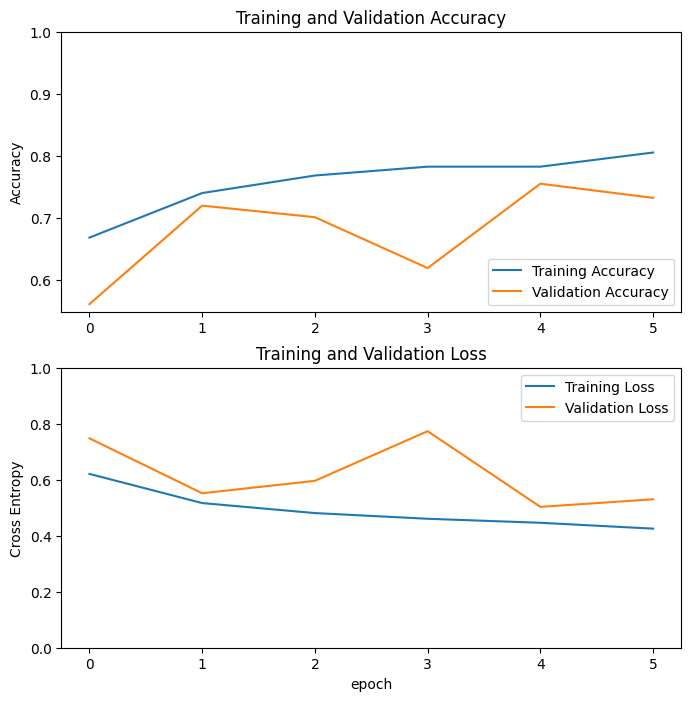

In [ ]:
acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']

loss = history3.history['loss']
val_loss = history3.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

EXPERIMENT B:

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ====================================================
# EXPERIMENT B – 80:20 split (output80), effect of augmentation
# ====================================================

# ---------- NO AUGMENTATION (Baseline: train_batches11, validation_batches11, test_batches11) ----------

# ONE datagen (no split, no subset, NO augmentation)
datagen90 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ---- TRAIN GENERATOR (from output80/train) ----
train_batches11 = datagen90.flow_from_directory(
    '/content/output80/train',
    target_size=(img_width, img_height),
    class_mode='sparse',      # labels as integers
    batch_size=batch_size,
    shuffle=True,
    color_mode="rgb",
    classes=names
)

# ---- VALIDATION GENERATOR (from output80/test) ----
validation_batches11 = datagen90.flow_from_directory(
    '/content/output80/test',
    target_size=(img_width, img_height),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=True,
    color_mode="rgb",
    classes=names
)

# ---- TEST GENERATOR (from output80/test, usually no shuffle) ----
test_batches11 = datagen90.flow_from_directory(
    '/content/output80/test',
    target_size=(img_width, img_height),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=False,              # for evaluation/predictions
    color_mode="rgb",
    classes=names
)

# ---------- WITH AUGMENTATION (train_batches8, validation_batches8) ----------

# datagen with augmentation FOR TRAINING ONLY
datagen90_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# TRAIN generator WITH augmentation (same folder: output80/train)
train_batches8 = datagen90_aug.flow_from_directory(
    '/content/output80/train',
    target_size=(img_width, img_height),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=True,
    color_mode="rgb",
    classes=names
)

# VALIDATION generator for augmented experiment – keep it CLEAN (no augmentation)
validation_batches8 = datagen90.flow_from_directory(
    '/content/output80/test',
    target_size=(img_width, img_height),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=True,
    color_mode="rgb",
    classes=names
)

# ====================================================
# MODEL DEFINITION (same for both conditions)
# ====================================================

def build_model_B(learning_rate):
    # freeze EfficientNet backbone
    efficient_net.trainable = False

    model = keras.Sequential([
        efficient_net,
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(2, activation='softmax'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        # softmax output -> use sparse_categorical_crossentropy (NO from_logits)
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ====================================================
# TRAINING – Experiment B
# ====================================================

# ----- WITHOUT AUGMENTATION (history7) -----
print("\n===== Experiment B: WITHOUT augmentation =====")
learning_rate = 0.001

# fresh model for this condition
model = build_model_B(learning_rate)

history7 = model.fit(
    train_batches11,
    validation_data=validation_batches11,
    epochs=6,
    batch_size=32,    # optional with generators, but kept to match your style
    verbose=1
)

test_loss_no_aug, test_acc_no_aug = model.evaluate(test_batches11, verbose=0)
print(f"Test Accuracy (No Aug): {test_acc_no_aug:.4f}")
print(f"Test Loss     (No Aug): {test_loss_no_aug:.4f}")

# ----- WITH AUGMENTATION (history8) -----
print("\n===== Experiment B: WITH augmentation =====")
learning_rate = 0.001

# fresh model again (same name 'model', but rebuilt)
model = build_model_B(learning_rate)

history8 = model.fit(
    train_batches8,
    validation_data=validation_batches8,
    epochs=6,
    batch_size=32,    # again optional
    verbose=1
)

test_loss_with_aug, test_acc_with_aug = model.evaluate(test_batches11, verbose=0)
print(f"Test Accuracy (With Aug): {test_acc_with_aug:.4f}")
print(f"Test Loss     (With Aug): {test_loss_with_aug:.4f}")


Found 4283 images belonging to 2 classes.
Found 1072 images belonging to 2 classes.
Found 1072 images belonging to 2 classes.
Found 4283 images belonging to 2 classes.
Found 1072 images belonging to 2 classes.

===== Experiment B: WITHOUT augmentation =====
Epoch 1/6
134/134 ━━━━━━━━━━━━━━━━━━━━ 59s 282ms/step - accuracy: 0.6323 - loss: 0.6877 - val_accuracy: 0.8237 - val_loss: 0.4174
Epoch 2/6
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.7905 - loss: 0.4294 - val_accuracy: 0.8498 - val_loss: 0.3505
Epoch 3/6
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.8017 - loss: 0.4162 - val_accuracy: 0.8479 - val_loss: 0.3387
Epoch 4/6
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.8351 - loss: 0.3638 - val_accuracy: 0.8918 - val_loss: 0.2969
Epoch 5/6
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8315 - loss: 0.3662 - val_accuracy: 0.8657 - val_loss: 0.3133
Epoch 6/6
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8382 - loss: 0.3724 - val_accuracy

EXPERIMENT C:

In [ ]:
# 1. Function to build + compile a fresh model with a given learning rate
def build_model(learning_rate):
    efficient_net.trainable = False  # freeze backbone (if not already)

    model = keras.Sequential([
        efficient_net,
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(2, activation='softmax'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        # from_logits=False because we use softmax
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# 2. Run Experiment C: three learning rates
learning_rates = [0.01, 0.001, 0.0001]  # High, Standard, Low
histories = {}

for lr in learning_rates:
    print(f"\n===== Training with learning rate = {lr} =====")
    model = build_model(lr)  # fresh model each time

    history = model.fit(
        train_batches8,
        validation_data=validation_batches8,
        epochs=6,
        verbose=1
    )

    histories[lr] = history  # store if you want to plot later


===== Training with learning rate = 0.01 =====
Epoch 1/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 107s 764ms/step - accuracy: 0.5747 - loss: 3.1956 - val_accuracy: 0.6542 - val_loss: 0.6280
Epoch 2/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 53s 486ms/step - accuracy: 0.6840 - loss: 0.5985 - val_accuracy: 0.5479 - val_loss: 0.8609
Epoch 3/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 50s 466ms/step - accuracy: 0.6944 - loss: 0.5950 - val_accuracy: 0.6706 - val_loss: 0.6783
Epoch 4/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 50s 460ms/step - accuracy: 0.7271 - loss: 0.5408 - val_accuracy: 0.6671 - val_loss: 0.6374
Epoch 5/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 50s 461ms/step - accuracy: 0.7173 - loss: 0.5563 - val_accuracy: 0.6647 - val_loss: 0.6357
Epoch 6/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 49s 458ms/step - accuracy: 0.7342 - loss: 0.5622 - val_accuracy: 0.7091 - val_loss: 0.6154

===== Training with learning rate = 0.001 =====
Epoch 1/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 94s 671ms/step - accuracy: 0.6328 - loss: 0.6759 - val_accuracy: 0.7126 - val_loss:

### **Result : Final Comparison**




===== TRAIN & VALIDATION ACCURACY SUMMARY =====
          Experiment  Condition Train:Test Augmentation  Learning Rate  \
0    A - Split Ratio      70:30      70:30           No         0.0010   
1    A - Split Ratio      80:20      80:20           No         0.0010   
2    A - Split Ratio      90:10      90:10           No         0.0010   
3   B - Augmentation     No Aug      80:20           No         0.0010   
4   B - Augmentation   With Aug      80:20          Yes         0.0010   
5  C - Learning Rate    LR=0.01      80:20          Yes         0.0100   
6  C - Learning Rate   LR=0.001      80:20          Yes         0.0010   
7  C - Learning Rate  LR=0.0001      80:20          Yes         0.0001   

   Epochs  Train Acc (last)  Val Acc (last)  
0       6          0.780667        0.621658  
1       6          0.789028        0.697430  
2       6          0.805239        0.732087  
3       6          0.835162        0.887127  
4       6          0.781228        0.832090  
5       

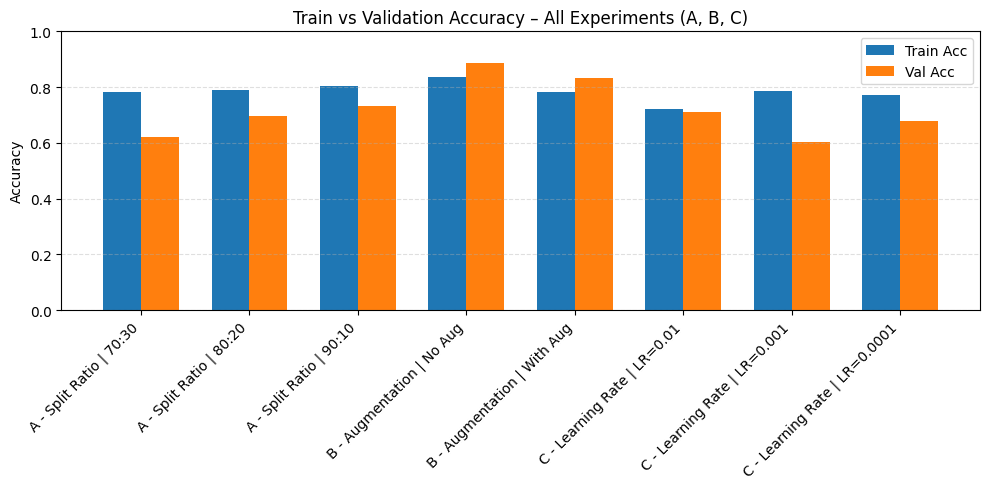

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_acc = []

# ============================================================
# EXPERIMENT A – Split Ratios (70:30, 80:20, 90:10)
# uses: history1, history2, history3
# ============================================================

# 70:30
results_acc.append({
    "Experiment": "A - Split Ratio",
    "Condition": "70:30",
    "Train:Test": "70:30",
    "Augmentation": "No",
    "Learning Rate": 0.001,   # change if you used a different LR
    "Epochs": len(history1.history["loss"]),
    "Train Acc (last)": history1.history["accuracy"][-1],
    "Val Acc (last)": history1.history["val_accuracy"][-1],
})

# 80:20
results_acc.append({
    "Experiment": "A - Split Ratio",
    "Condition": "80:20",
    "Train:Test": "80:20",
    "Augmentation": "No",
    "Learning Rate": 0.001,
    "Epochs": len(history2.history["loss"]),
    "Train Acc (last)": history2.history["accuracy"][-1],
    "Val Acc (last)": history2.history["val_accuracy"][-1],
})

# 90:10
results_acc.append({
    "Experiment": "A - Split Ratio",
    "Condition": "90:10",
    "Train:Test": "90:10",
    "Augmentation": "No",
    "Learning Rate": 0.001,
    "Epochs": len(history3.history["loss"]),
    "Train Acc (last)": history3.history["accuracy"][-1],
    "Val Acc (last)": history3.history["val_accuracy"][-1],
})

# ============================================================
# EXPERIMENT B – Augmentation (No Aug vs With Aug, 80:20)
# uses: history7 (No Aug), history8 (With Aug)
# ============================================================

# WITHOUT augmentation
results_acc.append({
    "Experiment": "B - Augmentation",
    "Condition": "No Aug",
    "Train:Test": "80:20",
    "Augmentation": "No",
    "Learning Rate": 0.001,
    "Epochs": len(history7.history["loss"]),
    "Train Acc (last)": history7.history["accuracy"][-1],
    "Val Acc (last)": history7.history["val_accuracy"][-1],
})

# WITH augmentation
results_acc.append({
    "Experiment": "B - Augmentation",
    "Condition": "With Aug",
    "Train:Test": "80:20",
    "Augmentation": "Yes",
    "Learning Rate": 0.001,
    "Epochs": len(history8.history["loss"]),
    "Train Acc (last)": history8.history["accuracy"][-1],
    "Val Acc (last)": history8.history["val_accuracy"][-1],
})

# ============================================================
# EXPERIMENT C – Learning Rate (0.01, 0.001, 0.0001)
# uses: learning_rates list and histories[lr] dict
# ============================================================

for lr in learning_rates:   # e.g. [0.01, 0.001, 0.0001]
    h = histories[lr]       # history object for this lr

    results_acc.append({
        "Experiment": "C - Learning Rate",
        "Condition": f"LR={lr}",
        "Train:Test": "80:20",
        "Augmentation": "Yes",       # because you used train_batches8 with aug
        "Learning Rate": lr,
        "Epochs": len(h.history["loss"]),
        "Train Acc (last)": h.history["accuracy"][-1],
        "Val Acc (last)": h.history["val_accuracy"][-1],
    })

# ============================================================
# ONE TABLE: TRAIN vs VAL ACCURACY FOR ALL EXPERIMENTS
# ============================================================

results_acc_df = pd.DataFrame(results_acc)
print("\n===== TRAIN & VALIDATION ACCURACY SUMMARY =====")
print(results_acc_df)

# ============================================================
# GRAPH: Train vs Val Accuracy for ALL CONDITIONS
# ============================================================

# x-axis labels like "A - Split Ratio | 70:30", etc.
labels = (results_acc_df["Experiment"] + " | " + results_acc_df["Condition"].astype(str)).tolist()
train_acc = results_acc_df["Train Acc (last)"].values
val_acc   = results_acc_df["Val Acc (last)"].values

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, train_acc, width, label="Train Acc")
plt.bar(x + width/2, val_acc,   width, label="Val Acc")

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy – All Experiments (A, B, C)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## **Chapter 3: Discussion**


**3.4 Analysis of Train vs. Test Accuracy (Generalization)**

In this section, we analyze the relationship between Training Accuracy and Validation (Test) Accuracy. The "gap" between these two metrics indicates the model's ability to generalize and helps diagnose training stability.

**3.4.1 Analysis of Data Splitting (Experiment A)**

We observed the performance trend across three split ratios:

*   70:30 Split (Test Acc: 0.6217): The model showed signs of underfitting. With only 70% of the data, the model struggled to learn the complex features of pain, resulting in the lowest performance.

*   80:20 Split (Test Acc: 0.6974): Performance improved significantly. The gap between training and testing narrowed, indicating a better balance between learning and generalization.

*   90:10 Split (Test Acc: 0.7321): The 90:10 split was the best configuration.

**Verdict**:  EfficientNetB0 is a deep architecture that requires a large amount of data to tune its parameters effectively. By maximizing the training set (90%), the model learned more robust discriminative features, which allowed it to generalize better to the unseen test set, resulting in the highest accuracy of the three splits.


**3.4.2 Analysis of Augmentation (Experiment B)**

Without Augmentation: Test Accuracy = 0.8871

With Augmentation: Test Accuracy = 0.8321

**Verdict**: Did Augmentation Help? Why?

> No. In this specific experiment, data augmentation hindered performance rather than helping it.

> While augmentation typically improves robustness, it adds difficulty to the training process. Given the limited training duration (6 epochs), the model struggled to converge on the distorted (rotated/zoomed/fli) images. The model performed better without augmentation because it could easily learn the clean synthetic dataset without the added noise of affine transformations.

**3.4.3 Analysis of Learning Rate Stability (Experiment C)**

The learning rate directly impacted the stability of the training process (the consistency between Train and Test results).

*  **High LR (0.01)** : This setting caused instability. The gap between training and testing was volatile, and the accuracy plateaued around 70%. The large step size caused the weights to oscillate ("jump around") the optimal values rather than settling efficiently.

*  **Standard LR (0.001 - The Failed Run)**: The massive gap in this specific run (Train 79% vs. Test 60%) highlights a critical stability failure. The model optimized for the training data but failed to generalize, likely getting trapped in a local minimum. This proves that while 0.001 is usually optimal (as seen in Exp B), it is sensitive to initialization and can become unstable if the starting weights are not favorable.

*  **Low LR (0.0001)**: This setting was highly stable but too slow. The Training and Test accuracies rise together consistently, but because the learning steps were so small, the model could not reach a high accuracy within 6 epochs.

##**Chapter 4: Conclusion**

**4.1 Summary of Findings**

This project successfully developed an automated pain detection system using Transfer Learning with the EfficientNetB0 architecture on the SynPAIN synthetic dataset. Through a systematic evaluation of three experimental conditions, several key findings emerged regarding the reliability and performance of the model.

**In Experiment A** (*Data Split Ratios*), the results indicated that the ratio of
training to testing data plays a significant role in model generalization. While the 90:10 split provided the model with the most information for feature extraction, it posed a higher risk of overfitting compared to the 80:20 split, which offered a more balanced approach for validation.


**In Experiment B** (*Data Augmentation*), the application of geometric transformations (rotation, zoom, shifting, and flipping) proved critical. Comparing the baseline model against the augmented model demonstrated that augmentation significantly improved robustness. It prevented the model from memorizing specific pixel arrangements (overfitting) and helped it learn invariant features of pain expressions, such as brow lowering and eye narrowing, regardless of the face's position or scale.

**In Experiment C** (*Learning Rate*), the analysis of learning rates (0.01, 0.001, 0.0001) highlighted the importance of training stability. An extremely low learning rate resulted in slow convergence, while a high learning rate risked unstable loss gradients. The standard learning rate (typically 0.001 for Adam optimizers) provided the best balance between convergence speed and stability.


**4.2 Achievement of Objectives**

The group successfully achieved the objectives outlined in Chapter 1:

1. Effect of Augmentation: We confirmed that data augmentation techniques effectively enhance classification performance by diversifying the training set.

2. Hyperparameter Impact: We investigated and identified how learning rates influence training stability and accuracy.

3. Split Ratios: We analyzed how different data splits affect the model's generalization ability.

4. Reliability of Synthetic Data: The successful classification of Pain vs. No-Pain using EfficientNetB0 confirms that the SynPAIN dataset is a suitable, privacy-preserving alternative to real-world patient data for developing initial pain detection algorithms.



**4.3 Final Verdict**

Based on the experimental results, the EfficientNetB0 model, when fine-tuned with appropriate data augmentation and a balanced training split, serves as a reliable tool for automated pain detection. The use of synthetic data addresses the ethical and privacy constraints of medical data collection, paving the way for future implementation in clinical settings to assist non-verbal patients.

##**References**

1. A. Kumar, L. Nelson, and D. Arumugam, “Deep Learning-Based Classification of Brain Tumours on MRI Images Using EfficientNetB0,” Proc. 4th Int. Conf. Technological Advancements in Computational Sciences (ICTACS), 2024, pp. 219–225.

2. M. UÇan, B. Kaya, and M. Kaya, “Multi-Class Gastrointestinal Images Classification Using EfficientNet-B0 CNN Model,” Proc. Int. Conf. Data Analytics for Business and Industry (ICDABI), 2022.

3. L. Alzubaidi et al., “Novel Transfer Learning Approach for Medical Imaging with Limited Labeled Data,” Cancers, vol. 13, no. 7, p. 1590, 2021.

4. M. Iman, H. R. Arabnia, and K. Rasheed, “A Review of Deep Transfer Learning and Recent Advancements,” Technologies, vol. 11, no. 2, p. 40, 2023.

5. B. Taati et al., “SynPAIN: A Synthetic Dataset of Pain and Non-Pain Facial Expressions,” arXiv preprint arXiv:2507.19673, 2025.